<a href="https://colab.research.google.com/github/nicecoconuts2/Evan_INFO4670_Spring2026/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> I believe a false negative is more costly. If a spam message reaches the user it can result in damages. However with a false positive, the most that could occur is an inconvience, such as missing a promotional offer.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> I believe recall should be the primary evaluation metric. It measures the actual amount of spam messages that are correctly identified. Since false negatives is more harmful, we want to maximize the recall to ensure as many as possible are caught.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> It would achieve 87% accuracy since only 13% are spam. It is still misleading however, because it would fail to identify any spam messages. It has high accuracy, but it has a 0% recall for spam.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


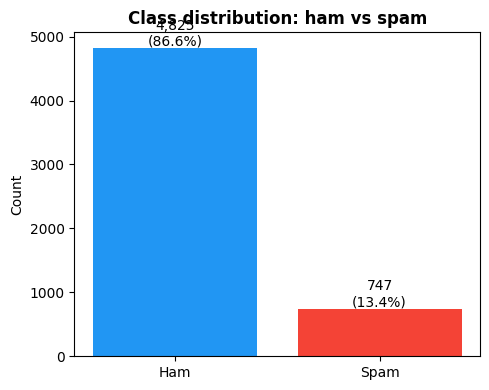

In [3]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


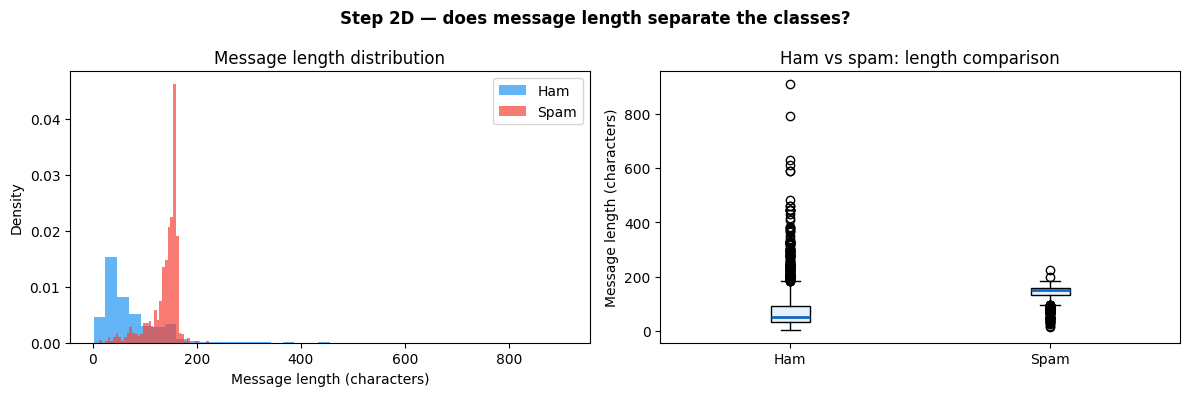

In [5]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [7]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    # d['feature_name'] = msg.str.contains(r'...', regex=True).astype(int)
    d['has_call_to_action'] = msg.str.contains(r'\b(txt|text|reply|call)\b', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    # d['feature_name'] = ...
    d['has_prize_words'] = msg.str.contains(r'\b(guaranteed|selected|congratulations|winner|prize)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_call_to_action     78.0%    7.0%  +71.1%
has_prize_words        16.9%    0.1%  +16.8%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


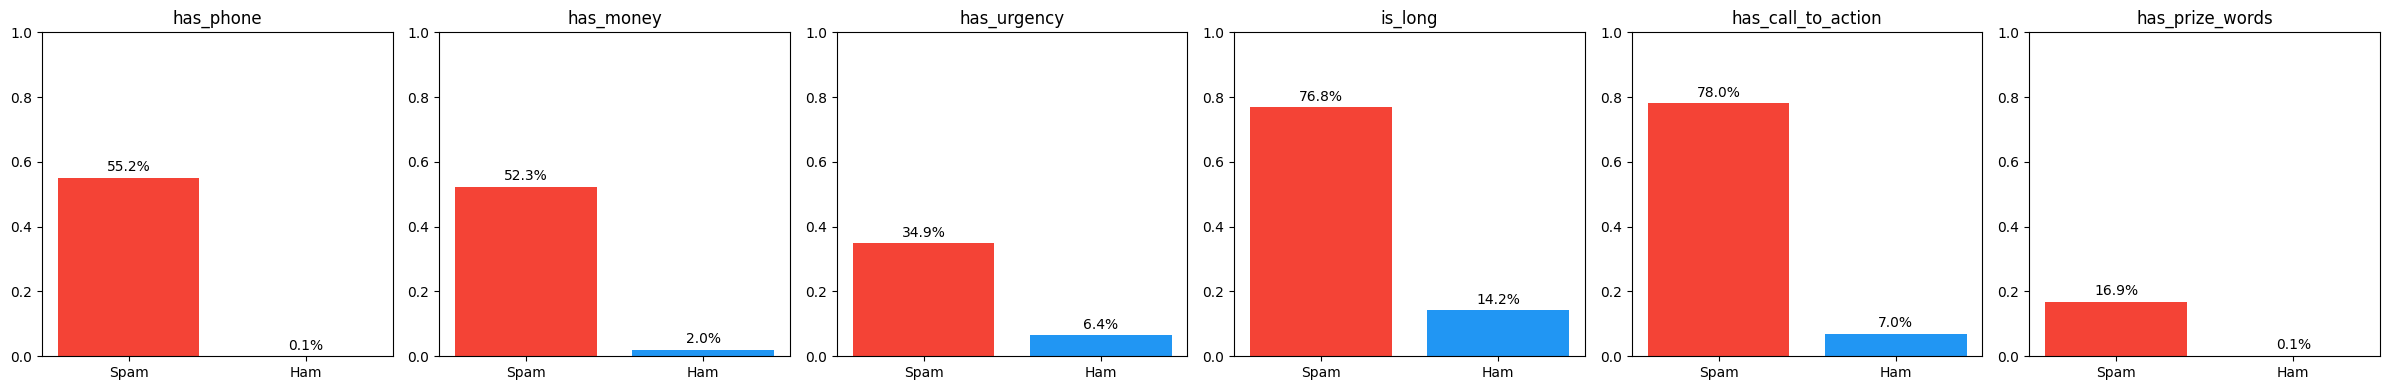

In [8]:
# Write your code here

n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 4))

# If only one feature, make axes iterable
if n_features == 1:
    axes = [axes]

for i, feat in enumerate(feature_cols):
    ax = axes[i]

    sp = df[df['spam'] == 1][feat].mean()
    ha = df[df['spam'] == 0][feat].mean()

    ax.bar(['Spam', 'Ham'], [sp, ha], color=['#F44336', '#2196F3'])
    ax.set_title(feat)
    ax.set_ylim(0, 1)

    # Add labels on bars
    ax.text(0, sp + 0.02, f'{sp:.1%}', ha='center')
    ax.text(1, ha + 0.02, f'{ha:.1%}', ha='center')

plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> has_call_to_action, it detects whether a message had action oriented words like "txt," "text," "reply," or "call.". It basically detects words that are prompting the user to do something, because its a strong signal that it's spam.

*Feature 2 — name and explanation:*
> has_prize_words, it identifies when a messages contains words like "guarantees," "selected," "congratulations," "winner," or "prize." These are identifiers for promotional spam and identifies reward based languages.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> has_call_to_action, it has a gap of +71%.

The large gap means the feature clearly seperates spam from ham messgaes. Because of this it's highly informative. When using a decision tree, featurs that have higher information gain are usually preferred at the root node because it reduces overall uncertainty the most. has_call_to_action distinguishes between the two classes so it provides high information gain.


**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> Something like "Your account has unusual activity. Please verify your information to avoid service interruption."

It doesn't contain either of the words that my feature would look for, but it still retains a subtle phising-style.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [19]:
# Write your code here

X = df[feature_cols].values
y = df['spam'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
#print sizes
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
#print spam rates to confirm stratification
print(f"Train spam rate: {y_train.mean():.3f}")
print(f"Test spam rate: {y_test.mean():.3f}")

Train size: 4179
Test size: 1393
Train spam rate: 0.134
Test spam rate: 0.134


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We pass it in order to keep the tain and test sets on the same proportion to the spam-to-ham. If it's imbalanced, skipping stratification could possibly create a split with not enough spam mesages in the training or test set. This could make learning and evaluation unreliable.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> I think I would prefer cross validation if there is a small dataset, or if I'm looking for more reliable estimates of performance. With cross validation you reduce the chance for overly dependent results.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 16


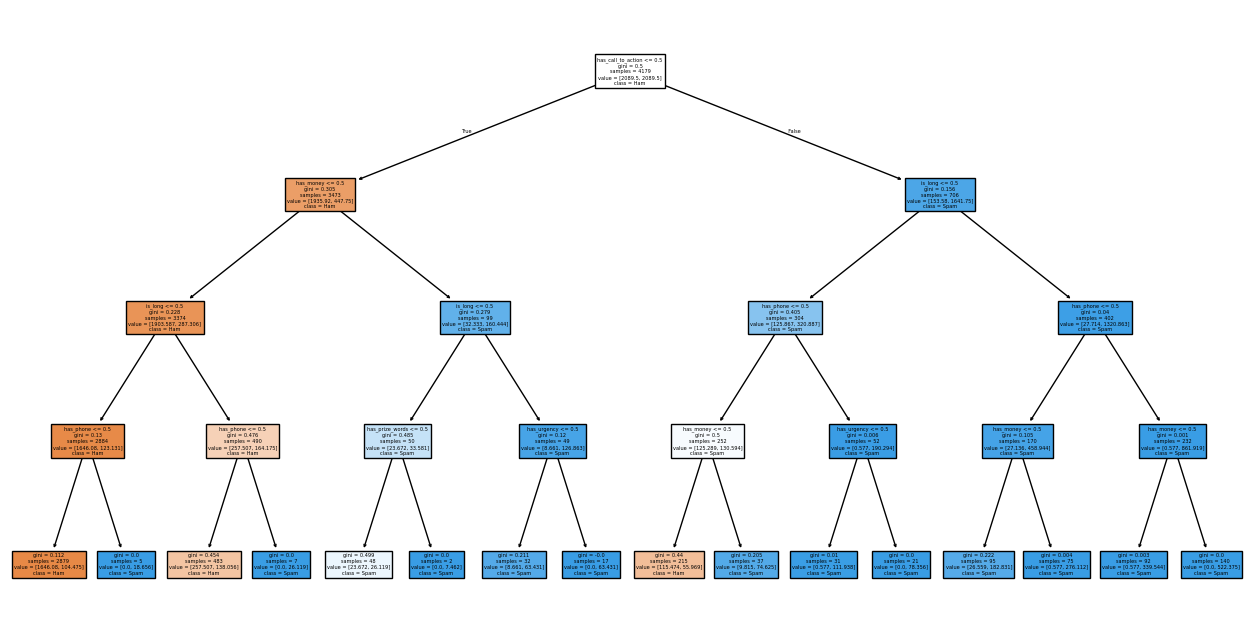

|--- has_call_to_action <= 0.50
|   |--- has_money <= 0.50
|   |   |--- is_long <= 0.50
|   |   |   |--- has_phone <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_phone >  0.50
|   |   |   |   |--- class: 1
|   |   |--- is_long >  0.50
|   |   |   |--- has_phone <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_phone >  0.50
|   |   |   |   |--- class: 1
|   |--- has_money >  0.50
|   |   |--- is_long <= 0.50
|   |   |   |--- has_prize_words <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_prize_words >  0.50
|   |   |   |   |--- class: 1
|   |   |--- is_long >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|--- has_call_to_action >  0.50
|   |--- is_long <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |

In [10]:
# Write your code here
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

print("Number of leaves:", dt.get_n_leaves())

plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True
)
plt.show()
print(export_text(dt, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


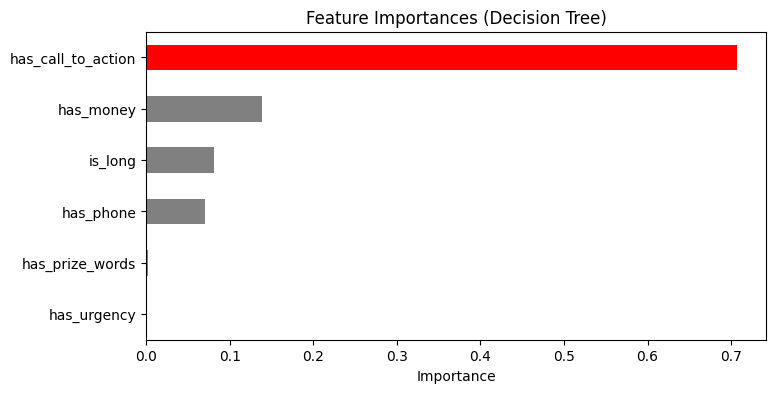

In [11]:
# Write your code here
importances = dt.feature_importances_

feat_imp = pd.Series(importances, index=feature_cols).sort_values()

colors = ['gray'] * len(feat_imp)
colors[-1] = 'red'  # highest importance
plt.figure(figsize=(8, 4))
feat_imp.plot(kind='barh', color=colors)
plt.title("Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


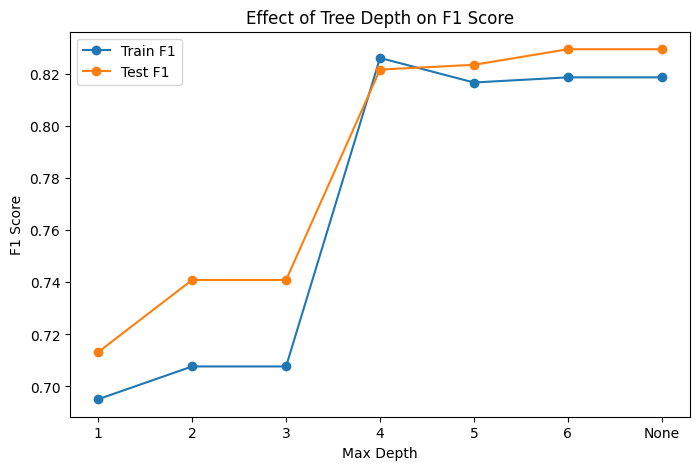

Depth=1: Train F1=0.695, Test F1=0.713
Depth=2: Train F1=0.708, Test F1=0.741
Depth=3: Train F1=0.708, Test F1=0.741
Depth=4: Train F1=0.826, Test F1=0.822
Depth=5: Train F1=0.817, Test F1=0.824
Depth=6: Train F1=0.819, Test F1=0.830
Depth=None: Train F1=0.819, Test F1=0.830


In [18]:
# Write your code here
depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42,
        class_weight='balanced'
    )
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

#labels for plotting
depth_labels = [str(d) for d in depths]
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_f1, marker='o', label='Train F1')
plt.plot(depth_labels, test_f1, marker='o', label='Test F1')
plt.title('Effect of Tree Depth on F1 Score')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

for d, tr, te in zip(depths, train_f1, test_f1):
    print(f"Depth={d}: Train F1={tr:.3f}, Test F1={te:.3f}")

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [13]:
# Write your code here
nb = BernoulliNB()

nb.fit(X_train, y_train)

y_train_pred_nb = nb.predict(X_train)
y_test_pred_nb = nb.predict(X_test)
print("Naive Bayes Performance:")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_nb):.3f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred_nb):.3f}")
print(f"Train F1:       {f1_score(y_train, y_train_pred_nb):.3f}")
print(f"Test F1:        {f1_score(y_test, y_test_pred_nb):.3f}")

Naive Bayes Performance:
Train Accuracy: 0.960
Test Accuracy:  0.958
Train F1:       0.851
Test F1:        0.842


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


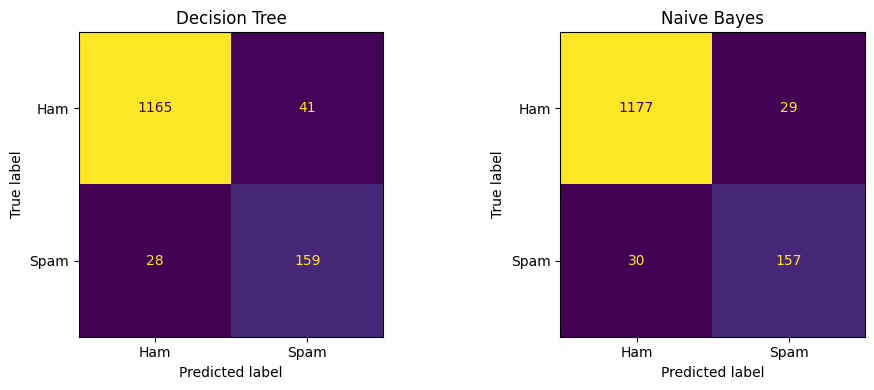

Decision Tree:
TP=159, FP=41, FN=28, TN=1165

Naive Bayes:
TP=157, FP=29, FN=30, TN=1177


In [14]:
# Write your code here

y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Naive Bayes')
plt.tight_layout()
plt.show()

tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()
print("Decision Tree:")
print(f"TP={tp_dt}, FP={fp_dt}, FN={fn_dt}, TN={tn_dt}")
print("\nNaive Bayes:")
print(f"TP={tp_nb}, FP={fp_nb}, FN={fn_nb}, TN={tn_nb}")

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.950467   0.795000  0.850267  0.821705
1    Naive Bayes  0.957645   0.844086  0.839572  0.841823


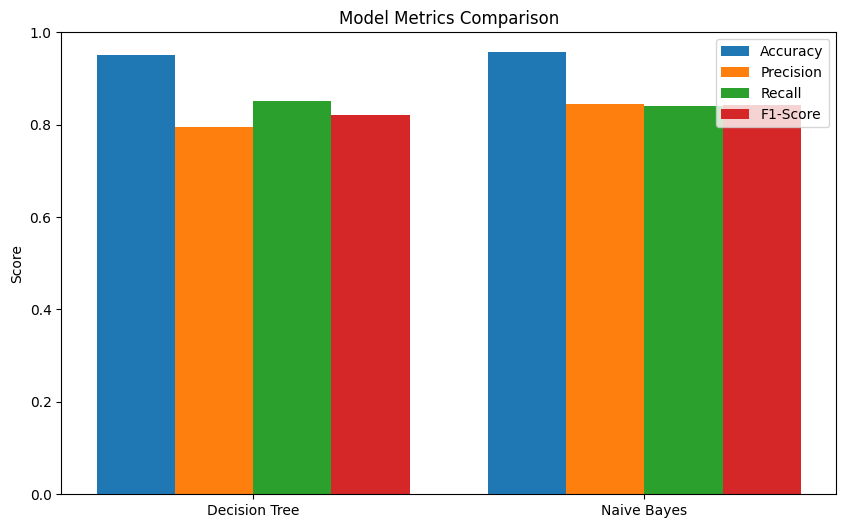

In [16]:
# Write your code here
#decision Tree metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

#naive Bayes metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

#build comparison table
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [dt_accuracy, nb_accuracy],
    'Precision': [dt_precision, nb_precision],
    'Recall': [dt_recall, nb_recall],
    'F1-Score': [dt_f1, nb_f1]
})
print(metrics_df)
#grouped bar chart
x = np.arange(len(metrics_df['Model']))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision')
plt.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall')
plt.bar(x + 1.5*width, metrics_df['F1-Score'], width, label='F1-Score')

plt.xticks(x, metrics_df['Model'])
plt.ylabel('Score')
plt.title('Model Metrics Comparison')
plt.ylim(0, 1)
plt.legend()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [17]:
# Write your code here
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
nb_model = BernoulliNB()
dt_scores = cross_val_score(dt_model, X, y, cv=skf, scoring='f1')
nb_scores = cross_val_score(nb_model, X, y, cv=skf, scoring='f1')

print("Decision Tree CV F1 scores:", dt_scores)
print("Decision Tree Avg F1:", dt_scores.mean())
print("\nNaive Bayes CV F1 scores:", nb_scores)
print("Naive Bayes Avg F1:", nb_scores.mean())

Decision Tree CV F1 scores: [0.85430464 0.80254777 0.86486486 0.802589   0.82352941]
Decision Tree Avg F1: 0.8295671359711102

Naive Bayes CV F1 scores: [0.86184211 0.83892617 0.86486486 0.83561644 0.84280936]
Naive Bayes Avg F1: 0.8488117895058653


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> True Positives: 159
False Negatives: 28
False Positives: 41

*Naive Bayes:*
> True Positives: 157
False Negatives: 30
False Positives: 29

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Recall was the primary metric because missing spam is more harmful than correctly flagging legit spam.

The decision tree was performing better on recall, it caught 159 spam messages compared to 157 for Naive bayes. A small difference but still favoring decision tree.

the cross validation results did confirm this trend, as decision tree maintained a slightly higher average F1 score.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I would recommend using decision tree for spam detection. It outperformed Naive Bayes by two detections. With a higher recall, tree decision makes a more effective approach at preventing harmful messages. The one weakness of decision tree is that it does produce more false positives, 12 more than Naive Bayes. We could potentially improve it by incorporating additional features and more advanced text representation in order to distinguish between spam and legit messages.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> has_prize_words might fail on more modern spam just because newer types of spam messages may avoid obvious promotional words to appear more legit.

The feature has_call_to_action might also fail becasue newer spam messages use more subtle and often professional language and avoid using explicit words like "txt" or "reply", which makes it harder to detect using simple keyword features.
